In [84]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import shap


In [72]:
#Data Specs
data = pd.read_csv("../../data/marketdata.csv")
print(len(data))

minority_class = (data['market_crisis']>0).sum()
majority_class = (data['market_crisis']==0).sum()
imbalance = minority_class/len(data)
print(minority_class)
print(majority_class)
print(imbalance)
print(data.columns.tolist())


4701
434
4267
0.09232078281216763
['Date', 'Vix', 'VIX_roll_10', 'VIX_roll_20', 'VIX_day_change', 'VIX_sd', 'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_VIX_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg', 'market_crisis']


In [73]:
#Train Test Split
X = data[['Vix', 'VIX_roll_10', 'VIX_roll_20', 'VIX_day_change', 'VIX_sd', 'SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_VIX_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg']]
y = data['market_crisis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

print(len(X_train), len(X_test))

3760 941


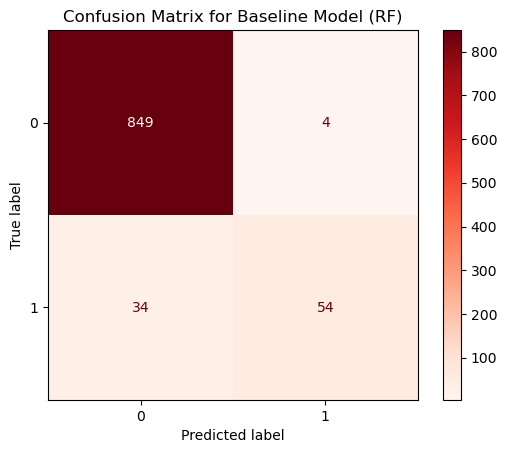

Train Acc:1.0
Test Acc:0.9596174282678002
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       853
           1       0.93      0.61      0.74        88

    accuracy                           0.96       941
   macro avg       0.95      0.80      0.86       941
weighted avg       0.96      0.96      0.96       941



In [74]:
#Baseline RF model
base_model = RandomForestClassifier()

base_model.fit(X_train, y_train)

base_train_acc = base_model.score(X_train, y_train)
base_test_acc = base_model.score(X_test, y_test)
base_pred = base_model.predict(X_test)
confusion = confusion_matrix(y_test, base_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Reds")
plt.title("Confusion Matrix for Baseline Model (RF)")
plt.savefig("../visualizations/RF_ML/baseline_matrix_RF.png")
plt.show()

print(f"Train Acc:{base_train_acc}")
print(f"Test Acc:{base_test_acc}")
print(classification_report(y_test, base_pred))




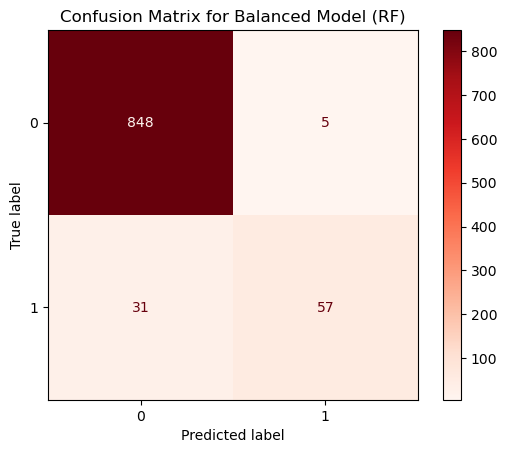

Train Acc:0.9965425531914893
Test Acc:0.9617428267800212
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       853
           1       0.92      0.65      0.76        88

    accuracy                           0.96       941
   macro avg       0.94      0.82      0.87       941
weighted avg       0.96      0.96      0.96       941



In [75]:
#Balanced RF Model with Max Tree Depth
balanced_model = RandomForestClassifier(
    class_weight="balanced",
    max_depth=10,
    n_estimators=100
)

balanced_model.fit(X_train, y_train)

balanced_train_acc = balanced_model.score(X_train, y_train)
balanced_test_acc = balanced_model.score(X_test, y_test)
balanced_pred = balanced_model.predict(X_test)
confusion = confusion_matrix(y_test, balanced_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=confusion)
conf_plot.plot(cmap="Reds")
plt.title("Confusion Matrix for Balanced Model (RF)")
plt.savefig("../visualizations/RF_ML/balanced_matrix_RF.png")
plt.show()

print(f"Train Acc:{balanced_train_acc}")
print(f"Test Acc:{balanced_test_acc}")
print(classification_report(y_test, balanced_pred))


market_crisis
0    3414
1    3414
Name: count, dtype: int64


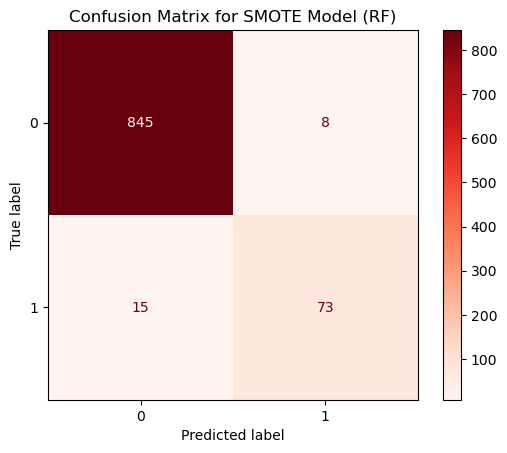

Train Acc:1.0
Test Acc:0.975557917109458
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       853
           1       0.90      0.83      0.86        88

    accuracy                           0.98       941
   macro avg       0.94      0.91      0.93       941
weighted avg       0.97      0.98      0.98       941



In [76]:
#Applying SMOTE
sm = SMOTE(random_state=101)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(pd.Series(y_train_sm).value_counts())

sm_baseline = RandomForestClassifier()
sm_baseline.fit(X_train_sm, y_train_sm)
sm_base_train_acc = sm_baseline.score(X_train_sm, y_train_sm)
sm_base_test_acc = sm_baseline.score(X_test, y_test)
sm_pred = sm_baseline.predict(X_test)

sm_conf = confusion_matrix(y_test, sm_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=sm_conf)
conf_plot.plot(cmap="Reds")
plt.title("Confusion Matrix for SMOTE Model (RF)")
plt.savefig("../visualizations/RF_ML/smote_matrix_RF.png")
plt.show()

print(f"Train Acc:{sm_base_train_acc}")
print(f"Test Acc:{sm_base_test_acc}")
print(classification_report(y_test, sm_pred))

In [77]:
print(sm_baseline.max_depth)
print(sm_baseline.n_estimators)
print(sm_baseline.min_samples_leaf)

None
100
1


In [78]:
param_grid = {
    'random_forest__n_estimators': [50, 100, 150, 200],
    'random_forest__max_depth': [None, 5, 10, 15],
    'random_forest__min_samples_leaf': [1, 3, 5, 7]
}

pipeline = Pipeline([
    ('smote', SMOTE(random_state=101)),
    ('random_forest', RandomForestClassifier(random_state=101))
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(f"Best params:{grid.best_params_}")
print(f"Best F1:{grid.best_score_}")

Best params:{'random_forest__max_depth': None, 'random_forest__min_samples_leaf': 3, 'random_forest__n_estimators': 200}
Best F1:0.8302117468164392


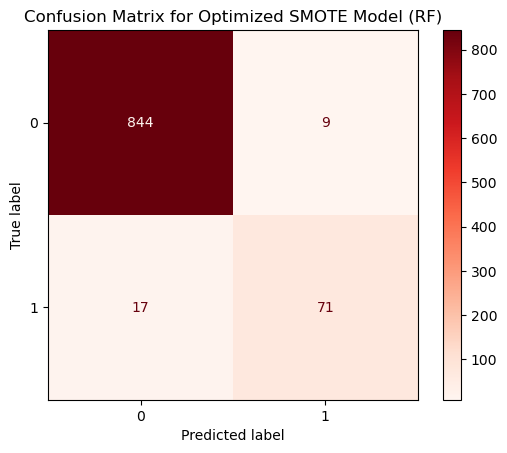

Train Acc:0.9976567076742824
Test Acc:0.9723698193411264
OOB Score:0.9844756883421206
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       853
           1       0.89      0.81      0.85        88

    accuracy                           0.97       941
   macro avg       0.93      0.90      0.92       941
weighted avg       0.97      0.97      0.97       941



In [79]:
#Best Model
X_sm, y_sm = SMOTE(random_state=101).fit_resample(X_train, y_train)

optimal_sm = RandomForestClassifier(min_samples_leaf=3, n_estimators=200, oob_score=True)
optimal_sm.fit(X_sm, y_sm)


best_model_train_acc = optimal_sm.score(X_sm, y_sm)
best_model_test_acc = optimal_sm.score(X_test, y_test)
best_model_pred = optimal_sm.predict(X_test)

best_sm_conf = confusion_matrix(y_test, best_model_pred)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=best_sm_conf)
conf_plot.plot(cmap="Reds")
plt.title("Confusion Matrix for Optimized SMOTE Model (RF)")
plt.savefig("../visualizations/RF_ML/opt_smote_matrix_RF.png")
plt.show()

print(f"Train Acc:{best_model_train_acc}")
print(f"Test Acc:{best_model_test_acc}")
print(f"OOB Score:{optimal_sm.oob_score_}")
print(classification_report(y_test, best_model_pred))


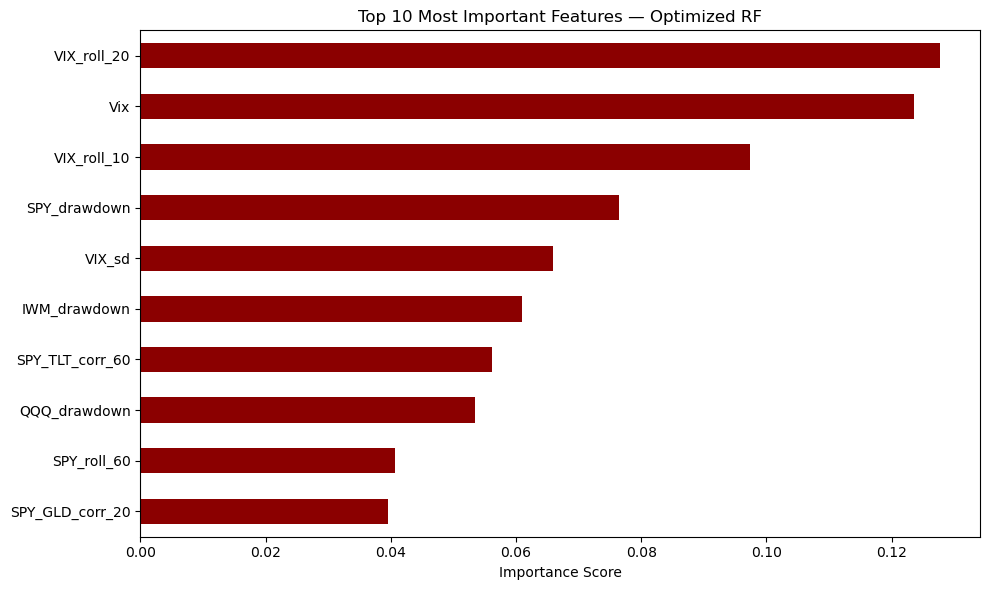

In [83]:
importances = pd.Series(
    optimal_sm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_10 = importances.head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='darkred')
plt.title("Top 10 Most Important Features — Optimized RF")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../visualizations/RF_ML/feature_importance_top10_RF.png")
plt.show()